In [98]:
# Autor:        Asier Ortiz García
# GitHub:       https://github.com/asier-ortiz/ai-course-notebooks/blob/main/entrega3_asier_ortiz.ipynb
# Kaggle:       -
# nbviewer:     https://nbviewer.org/github/asier-ortiz/ai-course-notebooks/blob/main/entrega3_asier_ortiz.ipynb

# Proyecto de IA basado en precios de pisos – Fase 3: Enfoques de NLP

En esta fase del proyecto se aplican técnicas de Procesamiento del Lenguaje Natural (NLP) para predecir el precio de viviendas en Madrid a partir de una descripcion de los mismos.

Se desarrollarán y compararán tres enfoques distintos:

1. **TF-IDF + modelos clásicos**: extracción de características con TF-IDF y regresores como Linear Regression, Ridge, Lasso, LinearSVR, SVR, Random Forest, AdaBoost, XGBoost y LGBM.
2. **Word Embeddings + CNN**: uso de Word2Vec y una red neuronal convolucional.
3. **Transformers**: fine-tuning de un modelo preentrenado en español (RoBERTa).

En cada caso se aplicará preprocesamiento, entrenamiento y evaluación mediante métricas de regresión (`MAE`, `MAE (%)`, `MSE`, `RMSE`, `R2`), y se realizará una comparativa final para determinar el enfoque más eficaz.


**Dataset**: [Idealista Madrid Listings](https://www.kaggle.com/datasets/fjcob1/idealista-madrid)
**Librerías**: `scikit-learn`, `nltk`, `gensim`, `transformers`, `pytorch`, `tensorflow`

## 1 - Importación de librerías y configuración inicial

In [99]:
# Librerías estándar
import importlib.util
import os
import re
import string
import subprocess
import warnings
from collections import Counter

# Visualización
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# IPython
from IPython.display import clear_output

# Carga de entorno y datos
from dotenv import load_dotenv
import kagglehub

# Procesamiento de texto y NLP
import nltk
import spacy
from gensim.models import Word2Vec
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize
from unidecode import unidecode

# Manejo de datos
import numpy as np
import pandas as pd

# Scikit-learn
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVR, SVR

# Modelos adicionales
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# Keras / TensorFlow
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Conv1D, Dense, Embedding, GlobalMaxPooling1D
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

In [100]:
# Establezco la coma como separador decimal en la salida de pandas
pd.options.display.float_format = lambda x: f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

In [101]:
#################################################################################################################################################

# Ref. https://spacy.io/models/es

# Ref. https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html
# Ref. https://simpletransformers.ai/
# Ref. https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html
# Ref. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html

# Ref. https://www.kaggle.com/code/pierremegret/gensim-word2vec-tutorial
# Ref. https://www.youtube.com/watch?v=Q2NtCcqmIww
# Ref. https://radimrehurek.com/gensim/apiref.html

# Ref. https://medium.com/@kalpit.sharma/mastering-random-forest-hyperparameter-tuning-for-enhanced-machine-learning-models-2d1a8c6c426f

# Ref. https://medium.com/@joachimiak.krzysztof/featurizing-text-for-regression-part-i-scikit-learn-5b45cb6b7029

# https://www.youtube.com/watch?v=ATK6fm3cYfI
# https://github.com/codebasics/nlp-tutorials/blob/main/12_tf_idf/tf_idf_tutorial_nlp_codebasics.ipynb

# Documentación de modelos clásicos utilizados:

    # AdaBoost
    # Ref. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostRegressor.html

    # Lasso
    # Ref. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html

    # LGBM
    # Ref. https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html

    # Linear Regression
    # Ref. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

    # LinearSVR
    # Ref. https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVR.html

    # Random Forest Regressor
    # Ref. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

    # Ridge Regression
    # Ref. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html

    # Support Vector Regressor
    # Ref. https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html

    # XGBoost Regressor
    # Ref. https://xgboost.readthedocs.io/en/stable/python/python_api/xgboost.XGBRegressor.html

#################################################################################################################################################

## 2 - Funciones y variables auxiliares

In [102]:
# Constantes
RANDOM_STATE = 42  # Semilla compartida para reproducibilidad

# Diccionario para almacenar resultados de cada enfoque (TF-IDF, Word2Vec y Transformers)
all_approaches_results = {}


# Funciones
def get_metrics(name, model, X_test, y_test_log, transform_target=True):
    """
    Calcula métricas estándar de regresión a partir de las predicciones del modelo.

    Parámetros:
    - name: nombre del modelo
    - model: modelo entrenado
    - X_test: datos de entrada para test
    - y_test_log: target de test (en escala logarítmica si transform_target=True)
    - transform_target: si es True, aplica expm1 para revertir el log1p del target

    Devuelve:
    - Diccionario con MAE, MSE, RMSE, R2 y MAE en porcentaje del precio medio
    """

    # Predicciones
    y_pred_log = model.predict(X_test)

    # Reversión del logaritmo si es necesario
    if transform_target:
        y_pred = np.expm1(y_pred_log)
        y_test = np.expm1(y_test_log)
    else:
        y_pred = y_pred_log
        y_test = y_test_log

    # Cálculo de métricas
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mae_pct = (mae / y_test.mean()) * 100

    return {
        "Model": name,
        "MAE": mae,
        "MAE (%)": mae_pct,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }


def plot_comparative_results(results_dict):
    """
    Genera gráficos comparativos de MAE y R² para distintos enfoques de modelado.

    Parámetros:
    - results_dict (dict): Diccionario donde cada clave es el nombre del enfoque (ej. 'TF-IDF, Word2Vec, Transformers')
      y cada valor es un DataFrame con métricas de modelos, que debe incluir las columnas 'Model', 'MAE' y 'R2'.
    """

    # Uno todos los DataFrames y añado la columna "Enfoque"
    combined_df = pd.concat([df.assign(Enfoque=name) for name, df in results_dict.items()], ignore_index=True)

    # Ordeno por MAE dentro de cada enfoque
    combined_df.sort_values(by=["Enfoque", "MAE"], inplace=True)

    # Paleta de colores por enfoque
    enfoque_palette = {
        name: color for name, color in zip(
            results_dict.keys(),
            sns.color_palette("Set2", n_colors=len(results_dict))
        )
    }

    # Subplot de MAE y R2 por modelo
    _, axes = plt.subplots(1, 2, figsize=(18, 6))

    # MAE
    sns.barplot(
        data=combined_df,
        y="Model",
        x="MAE",
        hue="Enfoque",
        dodge=True,
        ax=axes[0],
        palette=enfoque_palette
    )
    axes[0].set_title("Comparación de modelos por MAE")
    axes[0].set_xlabel("MAE (€)")
    axes[0].set_ylabel("Modelo")
    axes[0].invert_yaxis()
    axes[0].legend(title="Enfoque")

    # R²
    sns.barplot(
        data=combined_df,
        y="Model",
        x="R2",
        hue="Enfoque",
        dodge=True,
        ax=axes[1],
        palette=enfoque_palette
    )
    axes[1].set_title("Comparación de modelos por R²")
    axes[1].set_xlabel("R²")
    axes[1].set_ylabel("Modelo")
    axes[1].invert_yaxis()
    axes[1].legend(title="Enfoque")

    plt.tight_layout()
    plt.show()


## 3 - Carga de datos, análisis exploratorio y limpieza del dataset

### 3.1 - Carga o descarga del dataset

In [103]:
# Detecto si se está ejecutando en Kaggle
in_kaggle = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if in_kaggle:
    print("Ejecutando en Kaggle\n")

    # Ruta del dataset montado en "Input"
    dataset_dir = "/kaggle/input/idealista-madrid"

else:
    print("Ejecutando en entorno local\n")

    # Cargo la API key desde el fichero .env
    load_dotenv()
    os.environ["KAGGLE_API_KEY"] = os.getenv("KAGGLE_API_KEY")

    # Compruebo si ya tengo una copia local en ./data
    local_data_dir = os.path.join(os.getcwd(), "data")
    os.makedirs(local_data_dir, exist_ok=True)
    local_csv_path = os.path.join(local_data_dir, "Datos.csv")

    if os.path.exists(local_csv_path):
        print("CSV ya disponible localmente en ./data/")
        # Redirige dataset_dir para usar la carpeta local
        dataset_dir = local_data_dir
    else:
        # Descarga el dataset con kagglehub si no está ya en caché
        dataset_dir = os.path.expanduser("~/.cache/kagglehub/datasets/fjcob1/idealista-madrid")

        if not os.path.exists(dataset_dir):
            print("Dataset no encontrado en caché. Descargando desde Kaggle...")
            dataset_dir = kagglehub.dataset_download("fjcob1/idealista-madrid")
        else:
            print("Dataset encontrado en caché:", dataset_dir)

        # Busca el CSV y lo copia a ./data
        for root, dirs, files in os.walk(dataset_dir):
            for file in files:
                if file == "Datos.csv":
                    csv_path_temp = os.path.join(root, file)
                    pd.read_csv(csv_path_temp).to_csv(local_csv_path, index=False)
                    print(f"CSV copiado a: {local_csv_path}")
                    break
            else:
                continue
            break

# Obtengo la ruta al CSV final según el entorno
if in_kaggle:
    # Busca en el dataset descargado en Kaggle
    csv_path = os.path.join(dataset_dir, "Datos.csv")
else:
    # En local está en ./data con nombre Datos.csv
    csv_path = os.path.join("data", "Datos.csv")

# Cargo el dataset
if os.path.exists(csv_path):
    print(f"\nCSV encontrado: {csv_path}")
    df = pd.read_csv(csv_path)
else:
    print("No se encontró el archivo CSV esperado")

Ejecutando en entorno local

CSV ya disponible localmente en ./data/

CSV encontrado: data/Datos.csv


### 3.2 - Análisis exploratorio

In [104]:
# Reviso cómo son las primeras filas del dataset
print("Primeras filas del dataset:")
display(df.head())

Primeras filas del dataset:


,provincia,zona,titulo,PrecioActual,PrecioAnterior,metros,habitaciones,ascensor,localizacion,planta,baños,tags,descripcion,Enlace
0,madrid,ciudad-lineal,"Piso en calle de San Marcelo, 22, Ventas, Madrid",355000,0,69,"2,00",S,EXTERIOR,5ª,1,"VIVIENDA,LUMINOSO,VISTAS,REFORMADA,PORTERO,EXT...",Particular Vende vivienda totalmente reformada...,https://www.idealista.com/inmueble/106956987/
1,madrid,carabanchel,"Piso en calle Cabo Nicolás Mur, San Isidro, Ma...",149000,159000,91,"3,00",N,EXTERIOR,1ª,0,"PISO,EXCLUSIVA,INMOBILIARIA,OPORTUNIDAD",Inmobiliarias Encuentro vende en exclusiva la ...,https://www.idealista.com/inmueble/106906044/
2,madrid,centro,"Piso en calle de Rodas, Lavapiés-Embajadores, ...",195000,0,36,"1,00",S,NaN,2ª,0,"EXCLUSIVA,ESTUDIO",ESTUDIO EN PLENO CENTRO DE MADRIDSarago Servic...,https://www.idealista.com/inmueble/107306175/
3,madrid,usera,"Piso en calle de Ferroviarios, Almendrales, Ma...",195000,0,58,"1,00",S,INTERIOR,BAJO,0,"VIVIENDA,HOGAR,FUNCIONAL","Esta acogedora vivienda, ubicada en una planta...",https://www.idealista.com/inmueble/106325171/
4,madrid,tetuan,"Dúplex en Bellas Vistas, Madrid",715000,750000,140,"3,00",S,EXTERIOR,2ª,0,"TERRAZA,EXCLUSIVA,MODERNO","Maravilloso ATICO de reciente construcción, co...",https://www.idealista.com/inmueble/106627265/


In [105]:
# Muestra aleatoria del 10% del DataFrame original para pruebas
df = df.sample(frac=0.1, random_state=RANDOM_STATE).copy()

In [106]:
# Me quedo solo con las columnas necesarias para el análisis
df = df[["PrecioActual", "descripcion"]]
print(df.columns)

Index(['PrecioActual', 'descripcion'], dtype='object')


In [107]:
# Compruebo cuántas filas y columnas tiene el dataset tras la selección de columnas
print("Número de filas y columnas en el dataset:")
print(df.shape)

Número de filas y columnas en el dataset:
(1183, 2)


In [108]:
# Muestro el número de valores nulos por columna
print(df.isnull().sum())

PrecioActual    0
descripcion     2
dtype: int64


In [109]:
# Elimino filas con descripción nula, ya que sólo hay unos pocos casos y así evíto errores posteriores en el preprocesado
df = df.dropna(subset=["descripcion"]).copy()
print(f"Número de filas tras eliminar nulos: {len(df)}")

Número de filas tras eliminar nulos: 1181


In [110]:
# Muestro ejemplos de textos en la columna "descripcion"
df["descripcion"].sample(5, random_state=RANDOM_STATE)

4028     Oportunidad única en TetuánVivienda con potenc...
3520     Situada en una de las zonas más cotizadas de H...
1261     CO PROPERTY os presenta este amplio piso de ca...
914      Descubre este impresionante piso ubicado en la...
10597    LA CASA AGENCY OFRECE EN EXCLUSIVA EL ÁTICO DÚ...
Name: descripcion, dtype: object

In [111]:
# Muestro la longitud de los textos
df["descripcion"].str.len().describe()

count   1.181,00
mean      316,74
std        46,10
min        20,00
25%       315,00
50%       317,00
75%       319,00
max       614,00
Name: descripcion, dtype: float64

In [112]:
# Muestro el número de palabras por descripción
df["descripcion"].str.split().str.len().describe()

count   1.181,00
mean       49,75
std         8,32
min         2,00
25%        47,00
50%        50,00
75%        53,00
max        92,00
Name: descripcion, dtype: float64

In [113]:
# Muestro las palabras más frecuentes
all_words = " ".join(df["descripcion"].dropna().tolist()).split()
word_freq = Counter(all_words)
display(word_freq.most_common(20))

[('de', 4299),
 ('en', 2561),
 ('y', 1920),
 ('con', 1620),
 ('la', 1267),
 ('una', 1079),
 ('un', 833),
 ('el', 823),
 ('a', 816),
 ('piso', 545),
 ('vivienda', 502),
 ('para', 492),
 ('del', 460),
 ('que', 416),
 ('se', 379),
 ('las', 352),
 ('este', 313),
 ('planta', 303),
 ('cocina', 253),
 ('zona', 249)]

In [114]:
# Muestro las estadísticas descriptivas de la columna "PrecioActual"
print(df["PrecioActual"].describe())

count        1.181,00
mean     1.018.140,72
std      1.217.824,87
min         62.200,00
25%        285.000,00
50%        570.000,00
75%      1.300.000,00
max     13.000.000,00
Name: PrecioActual, dtype: float64


In [115]:
# Reviso si hay valores nulos, ceros o negativos en la columna "PrecioActual"
print("Valores nulos:", df["PrecioActual"].isna().sum())
print("Valores igual a 0:", (df["PrecioActual"] == 0).sum())
print("Valores menores que 0:", (df["PrecioActual"] < 0).sum())

Valores nulos: 0
Valores igual a 0: 0
Valores menores que 0: 0


In [116]:
# Detecto outliers en la columna "PrecioActual" utilizando IQR
Q1 = df["PrecioActual"].quantile(0.25)
Q3 = df["PrecioActual"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["PrecioActual"] < lower_bound) | (df["PrecioActual"] > upper_bound)]
print(f"Número de outliers: {len(outliers)}")

Número de outliers: 86


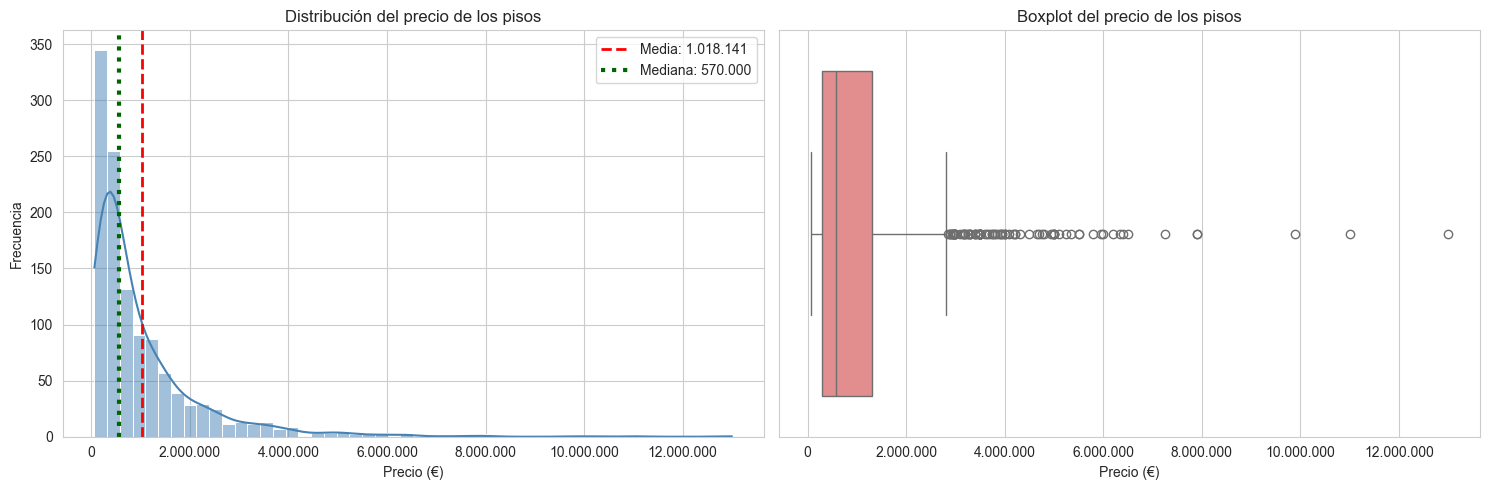

In [117]:
# Visualizo la distribución y los outliers del precio
_, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma
sns.histplot(df["PrecioActual"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].axvline(df["PrecioActual"].mean(), color='red', linestyle='dashed', linewidth=2,
                label=f'Media: {df["PrecioActual"].mean():,.0f}'.replace(",", "."))
axes[0].axvline(df["PrecioActual"].median(), color='darkgreen', linestyle="dotted", linewidth=3,
                label=f'Mediana: {df["PrecioActual"].median():,.0f}'.replace(",", "."))
axes[0].set_title("Distribución del precio de los pisos")
axes[0].set_xlabel("Precio (€)")
axes[0].set_ylabel("Frecuencia")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", ".")))
axes[0].legend()

# Boxplot
sns.boxplot(x=df["PrecioActual"], ax=axes[1], color="lightcoral")
axes[1].set_title("Boxplot del precio de los pisos")
axes[1].set_xlabel("Precio (€)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", ".")))

# Muestro las gráficas
plt.tight_layout()
plt.show()


### 3.3 - Tratamiento de outliers y transformación del precio

#### 3.3.1 - Eliminación de valores extremos

In [118]:
# Utilizo IQR para eliminar outliers del precio, ya que la distribución es muy asimétrica
# y presenta muchos valores extremos en el rango alto. Este enfoque mejora el rendimiento del modelo
# al reducir el impacto de datos atípicos que distorsionan el entrenamiento

# Eliminar outliers utilizando IQR
filtered_df = df[(df["PrecioActual"] >= Q1 - 1.5 * IQR) & (df["PrecioActual"] <= Q3 + 1.5 * IQR)].copy()

# Opción alternativa (no utilizada): filtrado manual por rango fijo:

# No escojo el filtrado manual porque impone límites arbitrarios que podrían eliminar
# datos válidos o introducir sesgos. En cambio, IQR es más flexible,
# basado en la propia distribución de los datos, y generaliza mejor si se cambia de dataset

# filtered_df = df[(df["PrecioActual"] >= 100_000) & (df["PrecioActual"] <= 350_000)].copy()

# Muestro cuántos datos se eliminaron tras aplicar el filtro
print(f"Número de registros antes: {len(df)}")
print(f"Número de registros después: {len(filtered_df)}")
print(f"Datos eliminados: {len(df) - len(filtered_df)}")

Número de registros antes: 1181
Número de registros después: 1095
Datos eliminados: 86


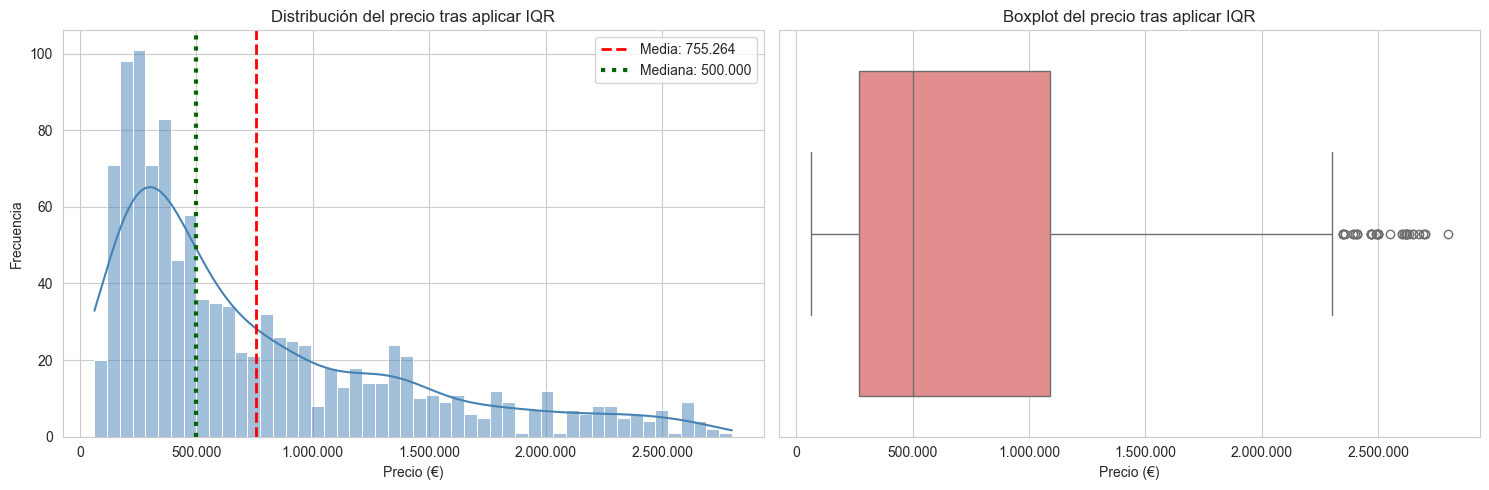

In [119]:
# Visualizo la distribución y los outliers tras aplicar el filtro IQR
_, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma
sns.histplot(filtered_df["PrecioActual"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].axvline(filtered_df["PrecioActual"].mean(), color='red', linestyle='dashed', linewidth=2,
                label=f'Media: {filtered_df["PrecioActual"].mean():,.0f}'.replace(",", "."))
axes[0].axvline(filtered_df["PrecioActual"].median(), color='darkgreen', linestyle="dotted", linewidth=3,
                label=f'Mediana: {filtered_df["PrecioActual"].median():,.0f}'.replace(",", "."))
axes[0].set_title("Distribución del precio tras aplicar IQR")
axes[0].set_xlabel("Precio (€)")
axes[0].set_ylabel("Frecuencia")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", ".")))
axes[0].legend()

# Boxplot
sns.boxplot(x=filtered_df["PrecioActual"], ax=axes[1], color="lightcoral")
axes[1].set_title("Boxplot del precio tras aplicar IQR")
axes[1].set_xlabel("Precio (€)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", ".")))

# Muestro las gráficas
plt.tight_layout()
plt.show()

In [120]:
# Muestro las estadísticas descriptivas tras aplicar IQR al precio
print(filtered_df["PrecioActual"].describe())

count       1.095,00
mean      755.264,10
std       634.087,58
min        62.200,00
25%       271.500,00
50%       500.000,00
75%     1.090.000,00
max     2.800.000,00
Name: PrecioActual, dtype: float64


#### 3.3.2 - Transformación logarítmica del target

In [121]:
# Aplico log(1 + x) al precio para reducir la asimetría y estabilizar la varianza.
# Esta transformación suaviza el efecto de los valores extremos y mejora el ajuste de los modelos lineales,
# que suelen funcionar mejor con distribuciones más normales.
filtered_df["PrecioLog"] = np.log1p(filtered_df["PrecioActual"])

In [122]:
# Verifico que no haya valores atípicos o problemas en la nueva columna
print("Resumen estadístico de PrecioLog:")
print(filtered_df["PrecioLog"].describe())

Resumen estadístico de PrecioLog:
count   1.095,00
mean       13,19
std         0,84
min        11,04
25%        12,51
50%        13,12
75%        13,90
max        14,85
Name: PrecioLog, dtype: float64


In [123]:
# Comparo directamente precio original y su versión logarítmica
print("\nComparativa: Precio original vs PrecioLog (primeras filas):")
display(filtered_df[["PrecioActual", "PrecioLog"]].head())


Comparativa: Precio original vs PrecioLog (primeras filas):


,PrecioActual,PrecioLog
8169,1634000,"14,31"
900,348000,"12,76"
8075,140000,"11,85"
7625,199900,"12,21"
2816,520000,"13,16"


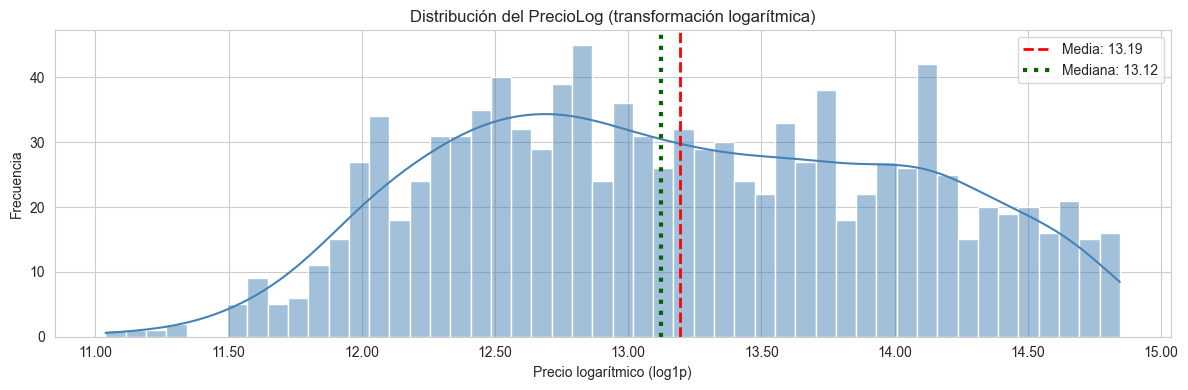

In [124]:
# Visualizo la nueva distribución del target transformado
plt.figure(figsize=(12, 4))
sns.histplot(filtered_df["PrecioLog"], bins=50, kde=True, color="steelblue")

# Añado la media y la mediana
plt.axvline(filtered_df["PrecioLog"].mean(), color='red', linestyle='dashed', linewidth=2,
            label=f'Media: {filtered_df["PrecioLog"].mean():.2f}')
plt.axvline(filtered_df["PrecioLog"].median(), color='darkgreen', linestyle="dotted", linewidth=3,
            label=f'Mediana: {filtered_df["PrecioLog"].median():.2f}')

plt.title("Distribución del PrecioLog (transformación logarítmica)")
plt.xlabel("Precio logarítmico (log1p)")
plt.ylabel("Frecuencia")
plt.legend()
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.2f}".replace(",", ".")))
plt.tight_layout()
plt.show()


## 4 - TF-IDF + modelos clásicos

### 4.1 - Preparación del texto con spaCy

In [125]:
# Verifico si el modelo ya está disponible antes de descargarlo
try:
    spacy.load("es_core_news_sm")
    print("El modelo 'es_core_news_sm' ya está instalado")
except OSError:
    print("Descargando el modelo 'es_core_news_sm'...")
    subprocess.run(["python", "-m", "spacy", "download", "es_core_news_sm"])
    clear_output(wait=True)
    print("Modelo descargado correctamente")

El modelo 'es_core_news_sm' ya está instalado


In [126]:
# Para este enfoque elimino URLs, números y signos de puntuación
# en lugar de enmascararlos porque no aportan valor y pueden meter ruido.
# En modelos como Word2Vec sí puede tener sentido usar máscaras del tipo <NUM>,
# pero aquí prefiero limpiar lo máximo posible antes de vectorizar

# Cargo el modelo de spaCy y las stopwords en español
nlp = spacy.load("es_core_news_sm")
spanish_stopwords = set(stopwords.words("spanish"))


def clean_text_lemmatized(text):
    """
    Limpia el texto y devuelve sólo las palabras lematizadas relevantes.
    Se eliminan URLs, números, signos de puntuación y stopwords.
    """
    # Limpieza previa
    text = text.lower()
    text = unidecode(text)
    text = re.sub(r"http\S+", "", text)  # Elimina URLs
    text = re.sub(r"[^\w\s]", "", text)  # Elimina puntuación
    text = re.sub(r"\d+", "", text)  # Elimina números

    # Proceso con spaCy
    doc = nlp(text)

    # Lematizo y me quedo sólo con las palabras útiles
    lemmas = [
        token.lemma_ for token in doc
        if token.lemma_.isalpha()  # Me aseguro de que solamente sean letras y descarto números y símbolos
           and token.lemma_ not in spanish_stopwords  # Elimino stopwords comunes en español que no aportan significado
           and len(token.lemma_) > 2  # Evito palabras muy cortas que suelen ser poco informativas
    ]

    return " ".join(lemmas)


# Aplico la limpieza creando una nueva columna
filtered_df["clean_description"] = filtered_df["descripcion"].astype(str).apply(clean_text_lemmatized)

### 4.2 - Análisis exploratorio de textos lematizados

In [127]:
# Comparo el texto original versus el texto limpio
print("Ejemplos antes y después de aplicar limpieza y lematización:")
sample = filtered_df[["descripcion", "clean_description"]].sample(5, random_state=RANDOM_STATE)
display(sample)

Ejemplos antes y después de aplicar limpieza y lematización:


,descripcion,clean_description
457,>>> Bajo con Terraza de más de 120 metros (Inc...,bajo terraza mas metro incluir tendedero promo...
101,Agencia inmobiliaria de madrid zona san bernar...,agencia inmobiliario madrid zona san bernardo ...
1277,PRECIO NO NEGOCIABLE-ABSTENERSE AGENCIAS E INT...,precio agencia intermediario exterior reformad...
7988,MASTERPISO vende piso duplex en calle Valle In...,masterpiso vender piso duplex calle valle incl...
8807,OPORTUNIDAD en rentabilidad alquilado por 1400...,oportunidad rentabilidad alquilado EUR largo e...


In [128]:
# Muestro las estadísticas de los textos limpios
print("\nEstadísticas de las descripciones lematizadas:")
print(filtered_df["clean_description"].str.len().describe())


Estadísticas de las descripciones lematizadas:
count   1.095,00
mean      232,21
std        34,43
min         7,00
25%       224,00
50%       233,00
75%       243,00
max       470,00
Name: clean_description, dtype: float64


In [129]:
# Muestro el número de palabras por descripción después de aplicar la limpieza
print("\nNúmero de palabras por descripción tras la limpieza:")
print(filtered_df["clean_description"].str.split().str.len().describe())


Número de palabras por descripción tras la limpieza:
count   1.095,00
mean       28,11
std         4,36
min         1,00
25%        27,00
50%        28,00
75%        30,00
max        57,00
Name: clean_description, dtype: float64


### 4.3 - División de los datos

In [130]:
# Divido el dataset usando "PrecioLog" como target
X_train, X_test, y_train, y_test = train_test_split(filtered_df["clean_description"], filtered_df["PrecioLog"],
                                                    test_size=0.2, random_state=RANDOM_STATE)

### 4.4 - Definición de parámetros y modelos

In [131]:
# Parámetros compartidos para todos los modelos

# Configuración base de TF-IDF
shared_tfidf_params = {
    "tfidf__max_df": [0.75, 0.9, 1.0],  # Filtra palabras muy frecuentes y poco informativas
    "tfidf__min_df": [1, 3, 5],  # Filtra palabras poco frecuentes que pueden meter ruido
    "tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],  # Uso unigramas, bigramas y trigramas para capturar más contexto
    "tfidf__sublinear_tf": [True],  # Aplico log(1 + tf) para reducir el impacto de palabras muy repetidas
    "tfidf__max_features": [5_000, 7_500, 10_000]  # Limito el tamaño del vocabulario para controlar la dimensionalidad
}

# Parámetros comunes para modelos de boosting
shared_boosting_params = {
    "model__n_estimators": [100, 200],  # Nº de árboles o iteraciones
    "model__learning_rate": [0.05, 0.1, 0.2]  # Tasa de aprendizaje ~> cuánto corrige cada nuevo árbol
}

# Profundidad de árboles para boosting
shared_tree_depth = {
    "model__max_depth": [3, 6, 10]  # Profundidad máxima de los árboles
}

In [132]:
# Diccionario de modelos y grids
models_and_params = {

    "AdaBoost": {
        "model": AdaBoostRegressor(random_state=RANDOM_STATE),
        "params": {
            **shared_tfidf_params,
            "model__n_estimators": [50, 100, 200],  # Número de árboles
            "model__learning_rate": [0.05, 0.1, 0.5, 1.0]  # Peso de cada nuevo modelo añadido
        }
    },

    "Lasso": {
        "model": Lasso(max_iter=10000, random_state=RANDOM_STATE),
        "params": {
            **shared_tfidf_params,
            "model__alpha": [0.01, 0.1, 1.0, 10.0]  # Regularización L1
        }
    },

    "LGBM": {
        "model": LGBMRegressor(random_state=RANDOM_STATE, verbose=-1),
        "params": {
            **shared_tfidf_params,
            **shared_boosting_params,
            **shared_tree_depth
        }
    },

    "LinearRegression": {
        "model": LinearRegression(),
        "params": {
            **shared_tfidf_params
        }
    },

    "LinearSVR": {
        "model": LinearSVR(max_iter=20_000, random_state=RANDOM_STATE),
        "params": {
            **shared_tfidf_params,
            "model__C": [0.01, 0.1, 1.0, 10.0],  # Regularización L2
            "model__epsilon": [0.0, 0.1, 0.2]  # Tolerancia a errores pequeños (margen)
        }
    },

    "RandomForest": {
        "model": RandomForestRegressor(random_state=RANDOM_STATE, verbose=0),
        "params": {
            **shared_tfidf_params,
            "model__n_estimators": [100, 200],  # Número de árboles
            "model__max_depth": [None, 10, 20]  # Profundidad máxima por árbol
        }
    },

    "Ridge": {
        "model": Ridge(),
        "params": {
            **shared_tfidf_params,
            "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]  # Regularización L2
        }
    },

    "SVR": {
        # Escalo los datos porque SVR es sensible a la escala de las variables.
        # Uso with_mean=False porque TF-IDF genera una matriz dispersa y no se puede centrar.
        "model": make_pipeline(StandardScaler(with_mean=False), SVR()),
        "params": {
            **shared_tfidf_params,
            "model__svr__C": [1, 10],  # Regularización C
            "model__svr__kernel": ["linear"]  # Kernel lineal para mayor eficiencia con TF-IDF
        }
    },

    "XGBoost": {
        "model": XGBRegressor(objective="reg:squarederror", random_state=RANDOM_STATE, verbosity=0),
        "params": {
            **shared_tfidf_params,
            **shared_boosting_params,
            **shared_tree_depth
        }
    },
}

### 4.5 - Entrenamiento de modelos y visualización de resultados

In [133]:
# Diccionario para almacenar los mejores modelos clásicos
best_classic_models = {}

# Entreno los todos los modelos definidos
for name, config in models_and_params.items():
    print(f"\nEntrenando modelo: {name}")

    # Pipeline con TfidfVectorizer y el modelo correspondiente
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("model", config["model"])
    ])

    # Búsqueda de hiperparámetros con GridSearchCV y validación cruzada
    grid = GridSearchCV(  # Ref. https://medium.com/%40Mandeep2002/gridsearchcv-key-concepts-8f98ceb633e4
        pipeline,
        config["params"],
        cv=5,
        # Nota recordatoria sobre las métricas para regresión:
            # - MAE (Mean Absolute Error): error medio absoluto, fácil de interpretar y menos sensible a outliers
            # - MSE (Error cuadrático medio): da más peso a los errores grandes, útil si queremos penalizar mucho las predicciones muy desviadas
            # - R2 (Coeficiente de determinación): indica qué proporción de la variabilidad del precio se explica por el modelo
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        verbose=1
    )

    # Entreno el modelo
    grid.fit(X_train, y_train)

    # Muestro los mejores hiperparámetros encontrados
    print(f"Mejores parámetros para {name}:")
    for param, value in grid.best_params_.items():
        print(f"   • {param}: {value}")

    # Guardo el mejor modelo para su evaluación posterior
    best_classic_models[name] = grid.best_estimator_



Entrenando modelo: AdaBoost
Fitting 5 folds for each of 972 candidates, totalling 4860 fits
Mejores parámetros para AdaBoost:
   • model__learning_rate: 0.05
   • model__n_estimators: 50
   • tfidf__max_df: 0.75
   • tfidf__max_features: 5000
   • tfidf__min_df: 1
   • tfidf__ngram_range: (1, 1)
   • tfidf__sublinear_tf: True

Entrenando modelo: Lasso
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Mejores parámetros para Lasso:
   • model__alpha: 0.01
   • tfidf__max_df: 0.75
   • tfidf__max_features: 5000
   • tfidf__min_df: 5
   • tfidf__ngram_range: (1, 1)
   • tfidf__sublinear_tf: True

Entrenando modelo: LGBM
Fitting 5 folds for each of 1458 candidates, totalling 7290 fits


/Users/asierortizgarcia/DocumentosMac/Git/module-2-notebooks/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/asierortizgarcia/DocumentosMac/Git/module-2-notebooks/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/asierortizgarcia/DocumentosMac/Git/module-2-notebooks/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/asierortizgarcia/DocumentosMac/Git/module-2-notebooks/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/asierortizgar

Mejores parámetros para LGBM:
   • model__learning_rate: 0.05
   • model__max_depth: 10
   • model__n_estimators: 200
   • tfidf__max_df: 0.75
   • tfidf__max_features: 5000
   • tfidf__min_df: 3
   • tfidf__ngram_range: (1, 1)
   • tfidf__sublinear_tf: True

Entrenando modelo: LinearRegression
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Mejores parámetros para LinearRegression:
   • tfidf__max_df: 0.75
   • tfidf__max_features: 10000
   • tfidf__min_df: 1
   • tfidf__ngram_range: (1, 2)
   • tfidf__sublinear_tf: True

Entrenando modelo: LinearSVR
Fitting 5 folds for each of 972 candidates, totalling 4860 fits
Mejores parámetros para LinearSVR:
   • model__C: 1.0
   • model__epsilon: 0.0
   • tfidf__max_df: 0.75
   • tfidf__max_features: 10000
   • tfidf__min_df: 1
   • tfidf__ngram_range: (1, 2)
   • tfidf__sublinear_tf: True

Entrenando modelo: RandomForest
Fitting 5 folds for each of 486 candidates, totalling 2430 fits
Mejores parámetros para RandomForest:
   • mod

/Users/asierortizgarcia/DocumentosMac/Git/module-2-notebooks/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mejores parámetros para XGBoost:
   • model__learning_rate: 0.2
   • model__max_depth: 6
   • model__n_estimators: 200
   • tfidf__max_df: 0.75
   • tfidf__max_features: 5000
   • tfidf__min_df: 3
   • tfidf__ngram_range: (1, 2)
   • tfidf__sublinear_tf: True


In [134]:
# Calculo las métricas de evaluación para cada modelo entrenado
metrics_list = [get_metrics(name, model, X_test, y_test) for name, model in best_classic_models.items()]

# Creo un DataFrame con las métricas y lo ordeno por MSE
metrics_df = pd.DataFrame(metrics_list)
metrics_df_sorted = metrics_df.sort_values(by="MSE").reset_index(drop=True)
display(metrics_df_sorted)

# Guardo los resultados de este enfoque para la posterior comparativa global
all_approaches_results["TF-IDF"] = metrics_df_sorted.copy()

/Users/asierortizgarcia/DocumentosMac/Git/module-2-notebooks/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Model,MAE,MAE (%),MSE,RMSE,R2
0,Ridge,"309.067,57","41,08","228.115.019.299,85","477.613,88","0,43"
1,LinearRegression,"310.034,56","41,21","229.194.354.007,11","478.742,47","0,42"
2,LinearSVR,"316.141,41","42,02","234.784.248.017,63","484.545,40","0,41"
3,SVR,"316.762,60","42,10","242.532.068.297,26","492.475,45","0,39"
4,LGBM,"341.200,53","45,35","261.462.933.720,38","511.334,46","0,34"
5,RandomForest,"336.208,54","44,69","270.243.033.239,55","519.849,05","0,32"
6,XGBoost,"340.654,41","45,28","274.398.946.337,44","523.831,03","0,31"
7,AdaBoost,"433.241,55","57,58","398.420.531.830,63","631.205,62","0,00"
8,Lasso,"468.742,40","62,30","436.549.183.430,89","660.718,69","-0,10"


## 5 - Word2Vec + CNN

In [135]:
# TODO :)

## 6 - Transformers

In [136]:
# TODO :)

## 7 - Comparación de resultados y análisis personal

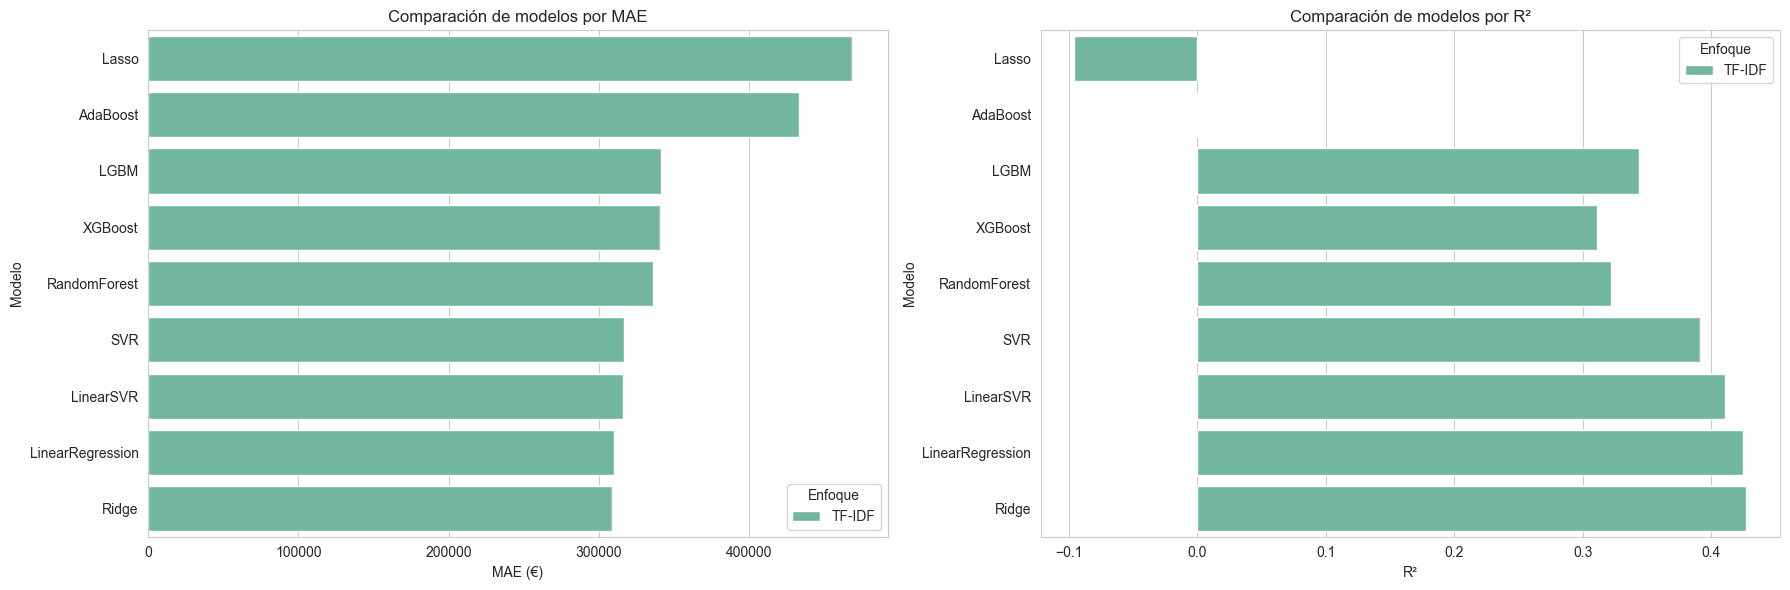

In [137]:
# Muestro los resultados de todos los modelos de los distintos enfoques
plot_comparative_results(all_approaches_results)